In [4]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [5]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [6]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [7]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

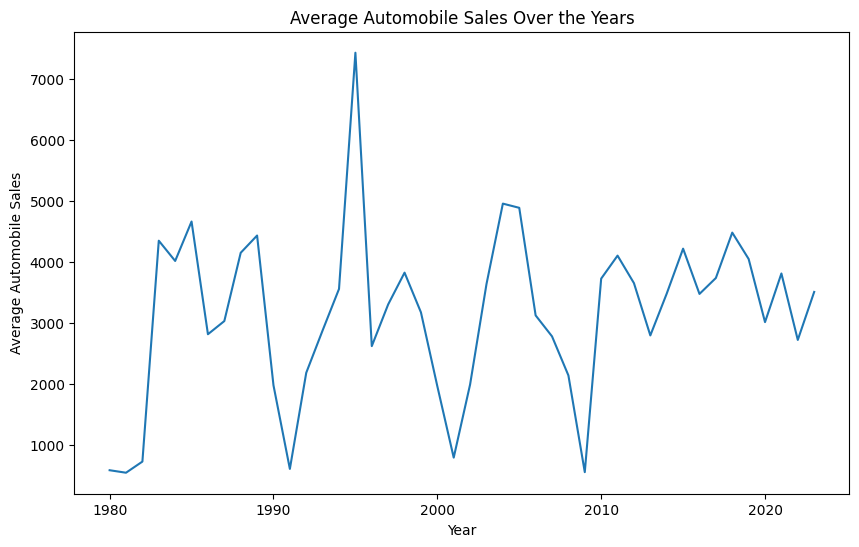

In [8]:
# Create data for plotting
df_line = df.groupby('Year')['Automobile_Sales'].mean()

# Create figure
plt.figure(figsize=(10, 6))
df_line.plot(kind='line')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales Over the Years')

plt.show()


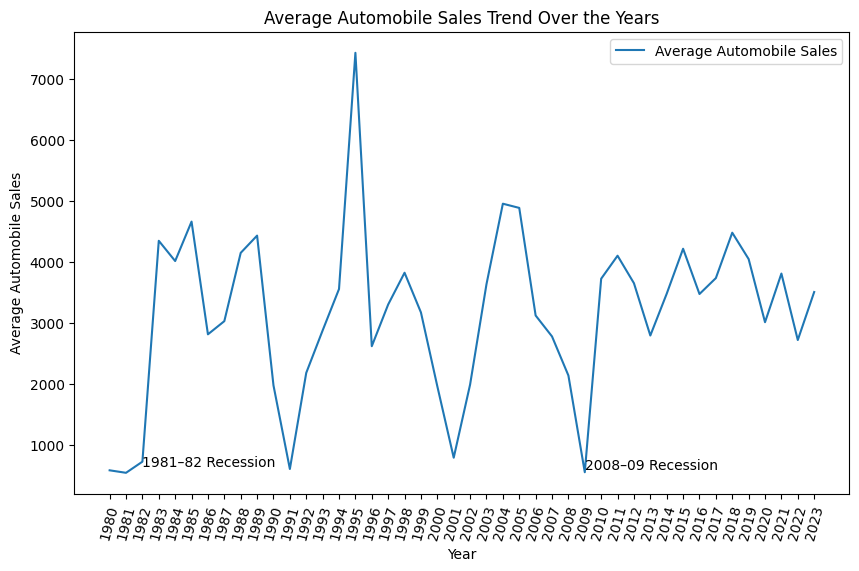

In [9]:
plt.figure(figsize=(10, 6))

# Create yearly average automobile sales
df_line = df.groupby('Year')['Automobile_Sales'].mean()

# Plot the line graph
df_line.plot(kind='line', label='Average Automobile Sales')

# Customize x-axis
plt.xticks(list(range(1980, 2024)), rotation=75)

# Labels and title
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales Trend Over the Years')

# Add recession annotations
plt.text(1982, 650, '1981–82 Recession')
plt.text(2009, 600, '2008–09 Recession')

# Legend and display
plt.legend()
plt.show()


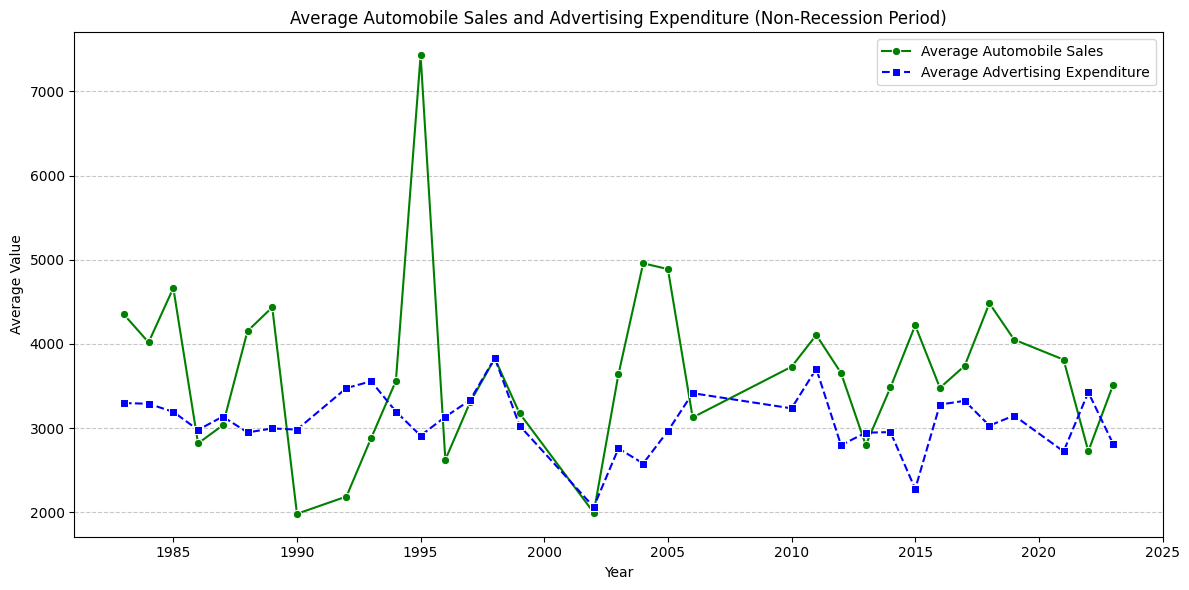

In [10]:
# Assuming 'df' is your dataset
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_trends,
    x='Year',
    y='Avg_Sales',
    marker='o',
    linestyle='-',
    color='green',
    label='Average Automobile Sales'
)

sns.lineplot(
    data=df_trends,
    x='Year',
    y='Avg_Ad_Spend',
    marker='s',
    linestyle='--',
    color='blue',
    label='Average Advertising Expenditure'
)

# Add labels, legend, title, and grid
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Average Automobile Sales and Advertising Expenditure (Non-Recession Period)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


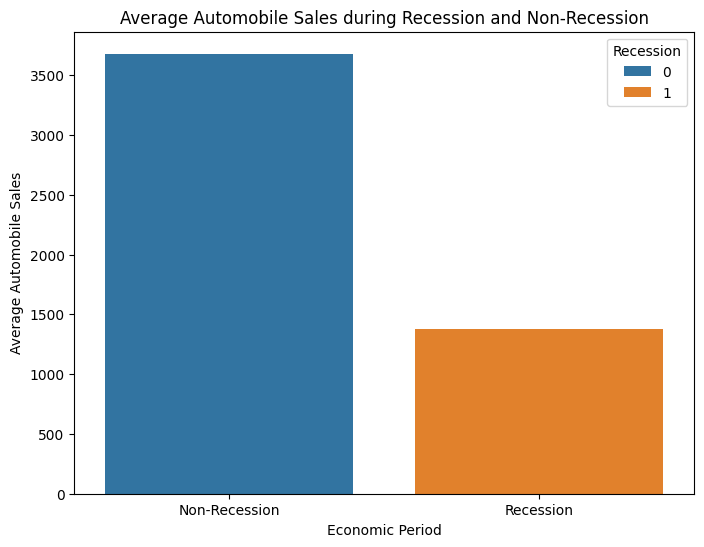

In [11]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession', data=new_df)

# Labels and title
plt.xlabel('Economic Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')

# Customize x-axis labels
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

plt.show()


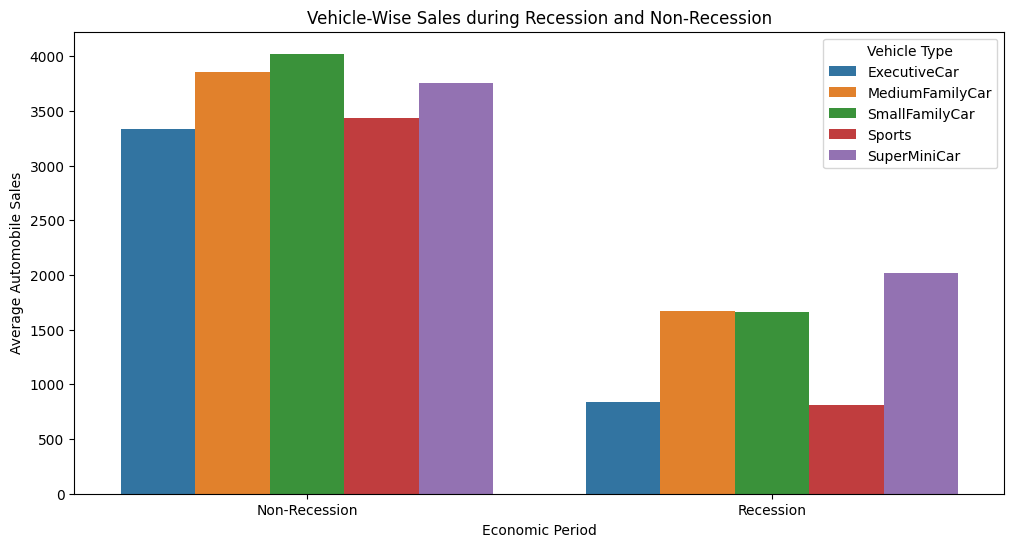

In [12]:
    # Group data by Recession and Vehicle Type
grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Create the grouped bar chart using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Recession',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    data=grouped_df
)

# Customize x-axis labels
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

# Labels and title
plt.xlabel('Economic Period')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession')

plt.legend(title='Vehicle Type')
plt.show()


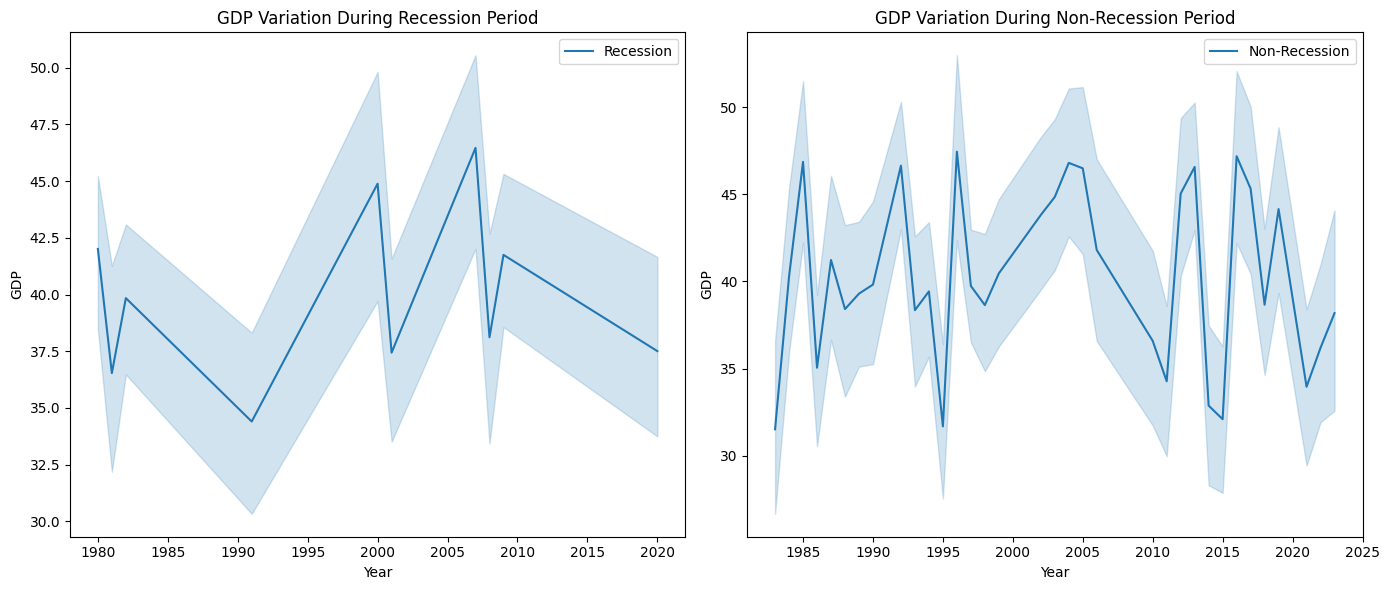

In [13]:
# Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

# Figure
fig = plt.figure(figsize=(14, 6))

# Create different axes for subplots
ax0 = fig.add_subplot(1, 2, 1)  # subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1, 2, 2)  # subplot 2 (1 row, 2 columns, second plot)

# Plot GDP variation during recession
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation During Recession Period')

# Plot GDP variation during non-recession
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation During Non-Recession Period')

plt.tight_layout()
plt.show()


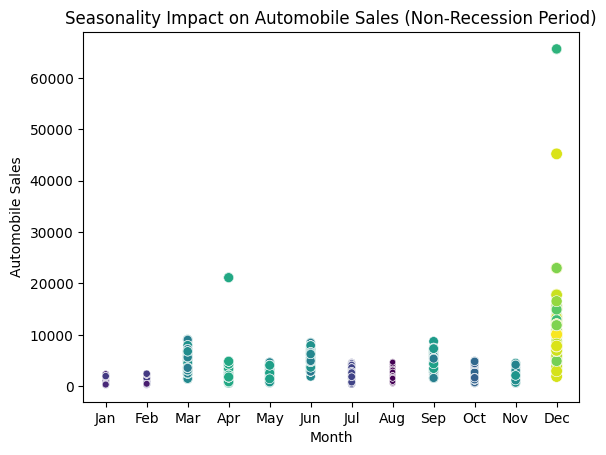

In [14]:
# Filter non-recession data
non_rec_data = df[df['Recession'] == 0]

# Size of bubbles based on seasonality weight
size = non_rec_data['Seasonality_Weight']

# Scatter plot with bubble effect
sns.scatterplot(
    data=non_rec_data,
    x='Month',                 # X-axis: Month
    y='Automobile_Sales',      # Y-axis: Sales
    size=size,                 # Bubble size based on Seasonality_Weight
    hue=size,                  # Optional: color intensity also based on seasonality
    palette='viridis',
    legend=False               # Optional: remove legend if cluttered
)

# Labels and title
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality Impact on Automobile Sales (Non-Recession Period)')

plt.show()


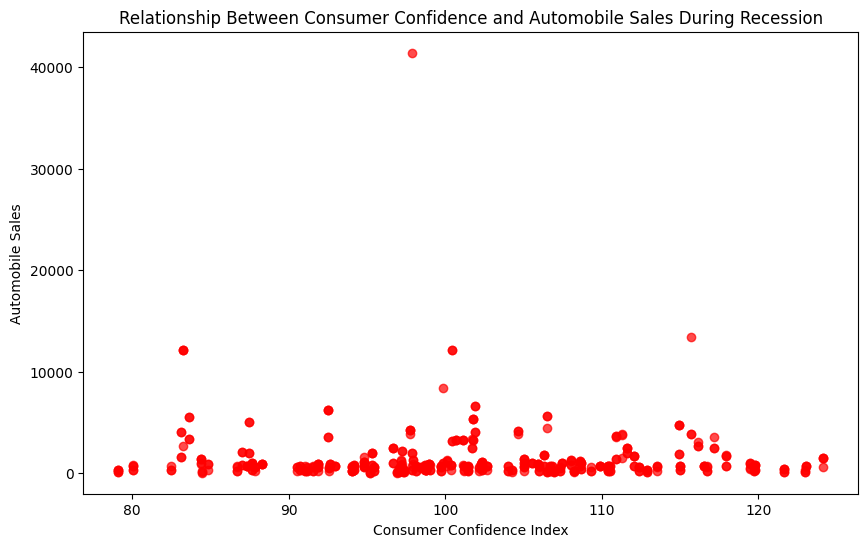

In [15]:
# Create dataframe for recession period
rec_data = df[df['Recession'] == 1]

# Scatter plot: Consumer Confidence vs Automobile Sales
plt.figure(figsize=(10, 6))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'], color='red', alpha=0.7)

# Labels and title
plt.xlabel('Consumer Confidence Index')
plt.ylabel('Automobile Sales')
plt.title('Relationship Between Consumer Confidence and Automobile Sales During Recession')

plt.show()


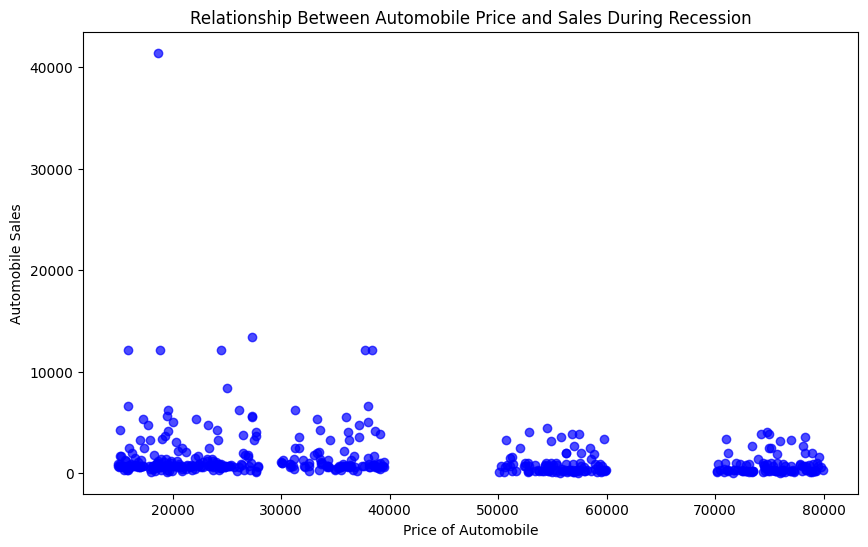

In [16]:
# Create dataframe for recession period
rec_data = df[df['Recession'] == 1]

# Scatter plot: Price vs Automobile Sales
plt.figure(figsize=(10, 6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], color='blue', alpha=0.7)

# Labels and title
plt.xlabel('Price of Automobile')
plt.ylabel('Automobile Sales')
plt.title('Relationship Between Automobile Price and Sales During Recession')

plt.show()


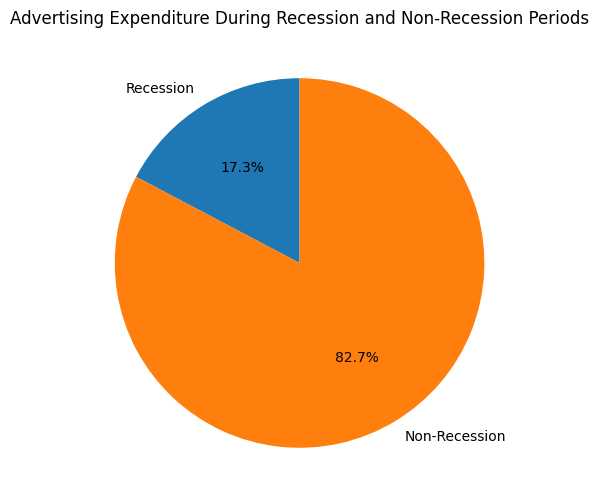

In [17]:
# Filter the data 
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure During Recession and Non-Recession Periods')

plt.show()


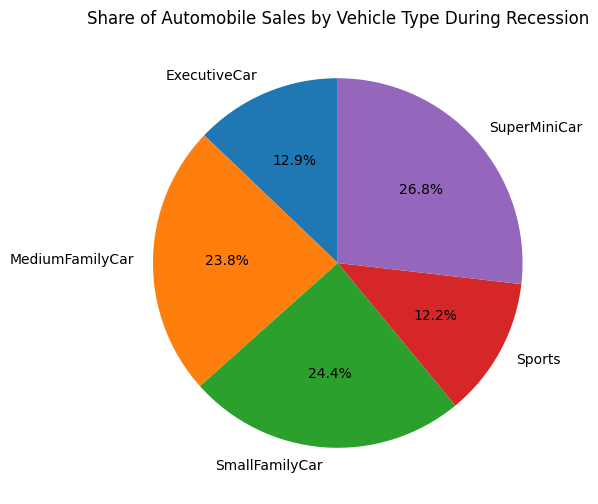

In [18]:
# Filter the data 
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Automobile_Sales'].sum()

# Create a pie chart for the share of each vehicle type in total sales during recessions
plt.figure(figsize=(8, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Share of Automobile Sales by Vehicle Type During Recession')

plt.show()


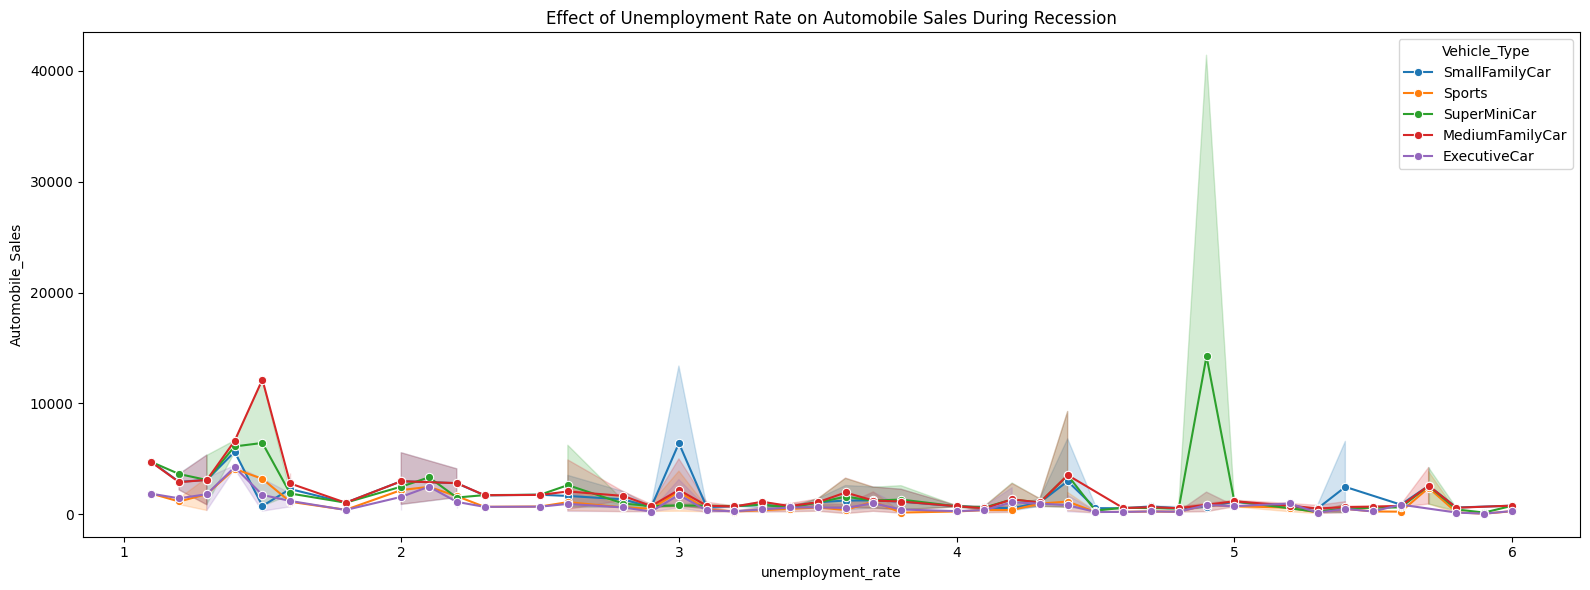

In [25]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=df_rec,
    x='unemployment_rate',       # use the exact column name from df.columns
    y='Automobile_Sales',
    hue='Vehicle_Type',
    marker='o'
)

plt.title('Effect of Unemployment Rate on Automobile Sales During Recession')
plt.xlabel('unemployment_rate')
plt.ylabel('Automobile_Sales')
plt.legend(title='Vehicle_Type')
plt.tight_layout()
plt.show()


In [22]:
print(df_rec.columns)


Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')


In [26]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json'
await download(path, "us-states.json")

filename = "us-states.json"

ModuleNotFoundError: No module named 'pyodide'

In [27]:
    # Filter the data for the recession period and specific cities
    recession_data = data[data['Recession'] == 1]

    # Calculate the total sales by city
    sales_by_city = recession_data.groupby('City')['Automobile_Sales'].sum().reset_index()

    # Create a base map centered on the United States
    map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

    # Create a choropleth layer using Folium
    choropleth = folium.Choropleth(
        geo_data= 'us-states.json',  # GeoJSON file with state boundaries
        data=sales_by_city,
        columns=['City', 'Automobile_Sales'],
        key_on='feature.properties.name',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='Automobile Sales during Recession'
    ).add_to(map1)


    # Add tooltips to the choropleth layer
    choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(['name'], labels=True)
    )

    # Display the map
    map1

NameError: name 'data' is not defined